# SQL in Python - Connecting to and retrieving data from PostgreSQL

Previously, you have learned how to connect to a SQL database by using a SQL client such as DBeaver. Apart from connecting to databases, DBeaver also allows you to run SQL queries against the database, create new tables and populate them with data as well as retrieving the data.

Python also allows executing SQL queries and getting the result into a Python object, for example a Pandas data frame. Instead of exporting a .csv file from DBeaver you can directly get the data you need into Python and continue your work. In addition we can reduce the steps by connecting to the database from Python directly, eliminating the need for a separate SQL client.

After you have the data in Python in the required shape you can export the data into a .csv file. This file is for your own reference, please avoid sending .csv files around - database is the point of reference when it comes to data. 

Having a copy of a .csv file (or another format) can speed up your analysis work. Imagine that the query takes 25 minutes to run. If you made some mistakes in your Python code you might need to go back to the original dataset. Instead of having to rerun the SQL query and having to wait you can read in the .csv file you have previously saved on your hard disk into Python and continue with your analysis work. 

**In this notebook you will see 2 ways to connect to SQL-Databases and export the data to a CSV file**


## Creating a connection to a PostgreSQL database with Python

There are 2 python packages that are the "go-to" when it comes to connecting to SQL-Databases: `psycopg2` and `sqlalchemy` 

### Connecting via psycopg2

In [1]:
import pandas as pd
import psycopg2


In order to create a connection to our PostgreSQL database we need the following information:

- host = the address of the machine the database is hosted on
- port = the virtual gate number through which communication will be allowed
- database = the name of the database
- user = the name of the user
- password = the password of the user

Because we don't want that the database information is published on github we put it into a `.env` file which is added into the `.gitignore`. 
In these kind of files you can store information that is not supposed to be published.
With the `dotenv` package you can read the `.env` files and get the variables.
(We will share the file with you on Slack!)


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

The function from the psycopg2 package to create a connection is called `connect()`.
`connect()` expects the parameters listed above as input in order to connect to the database.

In [3]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

### Retrieving data from the database with psycopg2

Before we can use our connection to get data, we have to create a cursor. A cursor allows Python code to execute PostgreSQL commmands in a database session.
A cursor has to be created with the `cursor()` method of our connection object conn.

In [4]:
cur = conn.cursor()

Now we can run SQL-Queries with `cur.execute('QUERY')` and then run `cur.fetchall()` to get the data:

In [5]:
cur.execute('SELECT * FROM eda.king_county_house_sales LIMIT 10')
cur.fetchall()

[(datetime.date(2014, 10, 13), 221900.0, 7129300520, 1),
 (datetime.date(2014, 12, 9), 538000.0, 6414100192, 2),
 (datetime.date(2015, 2, 25), 180000.0, 5631500400, 3),
 (datetime.date(2014, 12, 9), 604000.0, 2487200875, 4),
 (datetime.date(2015, 2, 18), 510000.0, 1954400510, 5),
 (datetime.date(2014, 5, 12), 1230000.0, 7237550310, 6),
 (datetime.date(2014, 6, 27), 257500.0, 1321400060, 7),
 (datetime.date(2015, 1, 15), 291850.0, 2008000270, 8),
 (datetime.date(2015, 4, 15), 229500.0, 2414600126, 9),
 (datetime.date(2015, 3, 12), 323000.0, 3793500160, 10)]

With `conn.close()` you can close the connection again.

In [6]:
#close the connection
conn.close()

But we want to work with the data. The easiest way is to import the data into pandas dataframes. We can use `pd.read_sql_query` or `pd.read_sql_table` or for convenience `pd.read_sql`.

This function is a convenience wrapper around read_sql_table and read_sql_query (for backward compatibility). It will delegate to the specific function depending on the provided input. A SQL query will be routed to read_sql_query , while a database table name will be routed to read_sql_table . Note that the delegated function might have more specific notes about their functionality not listed here.

In [7]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [8]:
# import the data into a pandas dataframe
query_string = """SELECT d.*, s.price, s.date
FROM eda.king_county_house_details d
LEFT JOIN eda.king_county_house_sales s
ON d.id = s.house_id;"""
df_psycopg = pd.read_sql(query_string, conn)

/var/folders/r8/w0fyhlh54rxd30pw66362ypr0000gn/T/ipykernel_33560/4167738020.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psycopg = pd.read_sql(query_string, conn)


In [9]:
#close the connection
conn.close()

In [10]:
df_psycopg.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,date
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,221900.0,2014-10-13
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,538000.0,2014-12-09
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,180000.0,2015-02-25
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,604000.0,2014-12-09
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,510000.0,2015-02-18


In [11]:
#export the data to a csv-file
df_psycopg.to_csv('data/eda.csv',index=False)

And then you can import that engine with a query into a pandas dataframe.

In [12]:
#import the data from a csv-file
df_import = pd.read_csv('data/eda.csv')

let us see how clean this data is

In [50]:
print(df_import.head()) 
print(df_import.info())
print(df_import.describe())
print(f"Number of missing Values: \n{df_import.isnull().sum()}")
print(f"Number of duplicate Values: \n{df_import.duplicated().sum()}")
print(f"Number of Unique Values per Column: \n{df_import.nunique()}")
print(f"Data Types: \n{df_import.dtypes}")
print(f"Columns: \n{df_import.columns}")
print(f"Number of unique Zipcoed: \n{df_import.zipcode.unique()}")

           id  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  7129300520       3.0       1.00       1180.0    5650.0     1.0         NaN   
1  6414100192       3.0       2.25       2570.0    7242.0     2.0         0.0   
2  5631500400       2.0       1.00        770.0   10000.0     1.0         0.0   
3  2487200875       4.0       3.00       1960.0    5000.0     1.0         0.0   
4  1954400510       3.0       2.00       1680.0    8080.0     1.0         0.0   

   view  condition  grade  ...  sqft_basement  yr_built  yr_renovated  \
0   0.0          3      7  ...            0.0      1955           0.0   
1   0.0          3      7  ...          400.0      1951       19910.0   
2   0.0          3      6  ...            0.0      1933           NaN   
3   0.0          5      7  ...          910.0      1965           0.0   
4   0.0          3      8  ...            0.0      1987           0.0   

   zipcode      lat     long  sqft_living15  sqft_lot15     price       da

Plotting time vs price

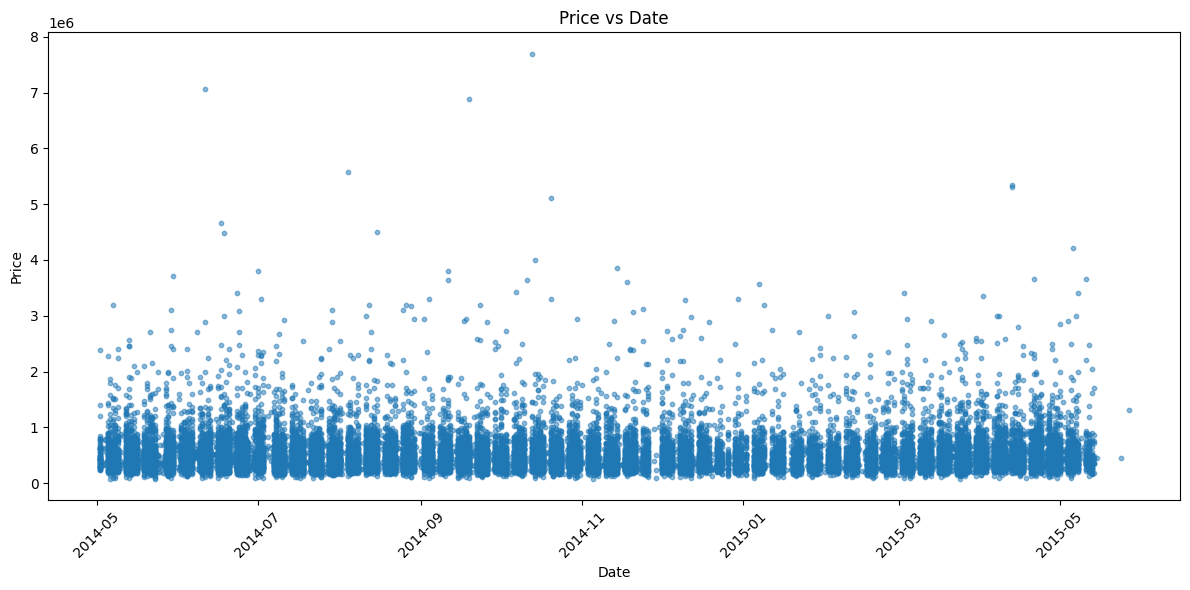

In [37]:
# ...existing code...
import matplotlib.pyplot as plt
# If running in a Jupyter notebook, enable inline plotting
# (keep or remove the next line depending on your notebook setup)
%matplotlib inline

# ensure date and price have correct dtypes
df_import['date'] = pd.to_datetime(df_import['date'], errors='coerce')
df_import['price'] = pd.to_numeric(df_import['price'], errors='coerce')

# drop rows missing the needed values and sort by date
df_plot = df_import.dropna(subset=['date', 'price']).sort_values('date')

# scatter plot price vs date
plt.figure(figsize=(12, 6))
plt.scatter(df_plot['date'], df_plot['price'], alpha=0.5, s=10)
plt.title('Price vs Date')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Geoplotting with the price as color

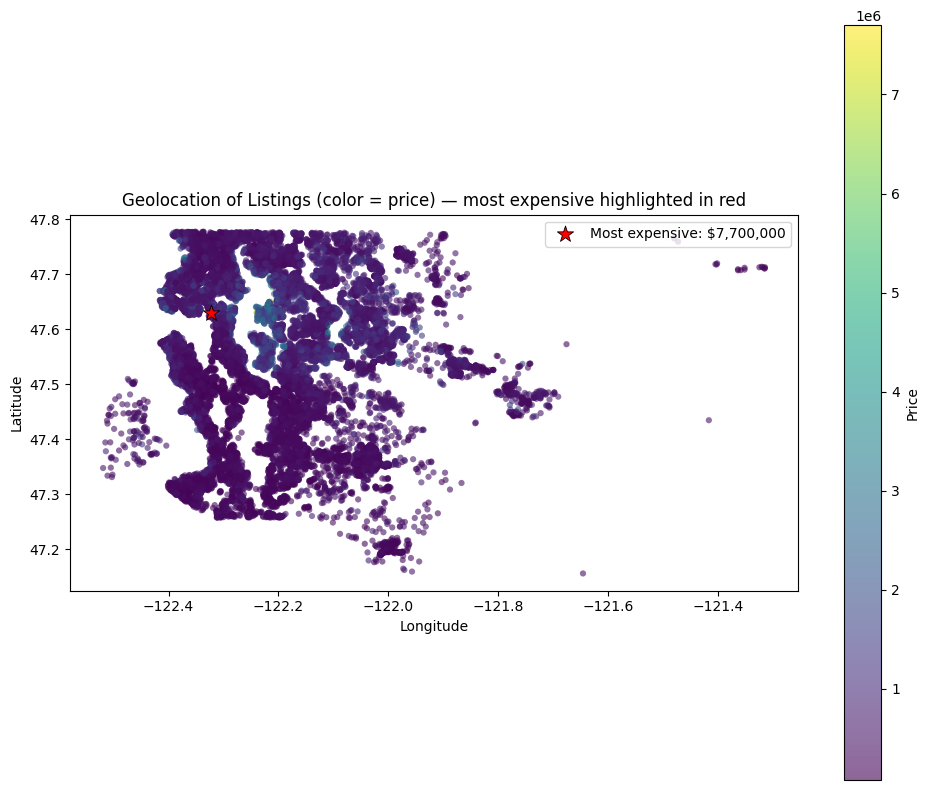

In [38]:
# ...existing code...
import matplotlib.pyplot as plt
# If running in a Jupyter notebook, enable inline plotting
%matplotlib inline

# try common latitude/longitude column names
lat_candidates = ['lat', 'latitude', 'Lat', 'Latitude']
lon_candidates = ['long', 'lon', 'longitude', 'Long', 'Longitude']

lat_col = next((c for c in lat_candidates if c in df_import.columns), None)
lon_col = next((c for c in lon_candidates if c in df_import.columns), None)

if lat_col is None or lon_col is None:
    print("Latitude/longitude columns not found. Available columns:", list(df_import.columns))
else:
    # ensure numeric types
    df_import[lat_col] = pd.to_numeric(df_import[lat_col], errors='coerce')
    df_import[lon_col] = pd.to_numeric(df_import[lon_col], errors='coerce')
    df_import['price'] = pd.to_numeric(df_import['price'], errors='coerce')

    df_map = df_import.dropna(subset=[lat_col, lon_col, 'price']).copy()

    if df_map.empty:
        print("No rows with valid lat/lon/price to plot.")
    else:
        # base scatter colored by price
        plt.figure(figsize=(10, 8))
        sc = plt.scatter(
            df_map[lon_col],
            df_map[lat_col],
            c=df_map['price'],
            cmap='viridis',
            s=20,
            alpha=0.6,
            linewidth=0,
            rasterized=True
        )
        cbar = plt.colorbar(sc)
        cbar.set_label('Price')

        # highlight the single most expensive point in red
        idx_max = df_map['price'].idxmax()
        most_exp = df_map.loc[idx_max]
        plt.scatter(
            most_exp[lon_col],
            most_exp[lat_col],
            c='red',
            s=150,
            marker='*',
            edgecolor='k',
            linewidth=0.6,
            label=f"Most expensive: ${int(most_exp['price']):,}"
        )
        plt.legend(loc='upper right')

        plt.title('Geolocation of Listings (color = price) — most expensive highlighted in red')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.tight_layout()
        plt.show()
# ...existing code...

color by zip code to see if every one has zipcode

/var/folders/r8/w0fyhlh54rxd30pw66362ypr0000gn/T/ipykernel_33560/476774444.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


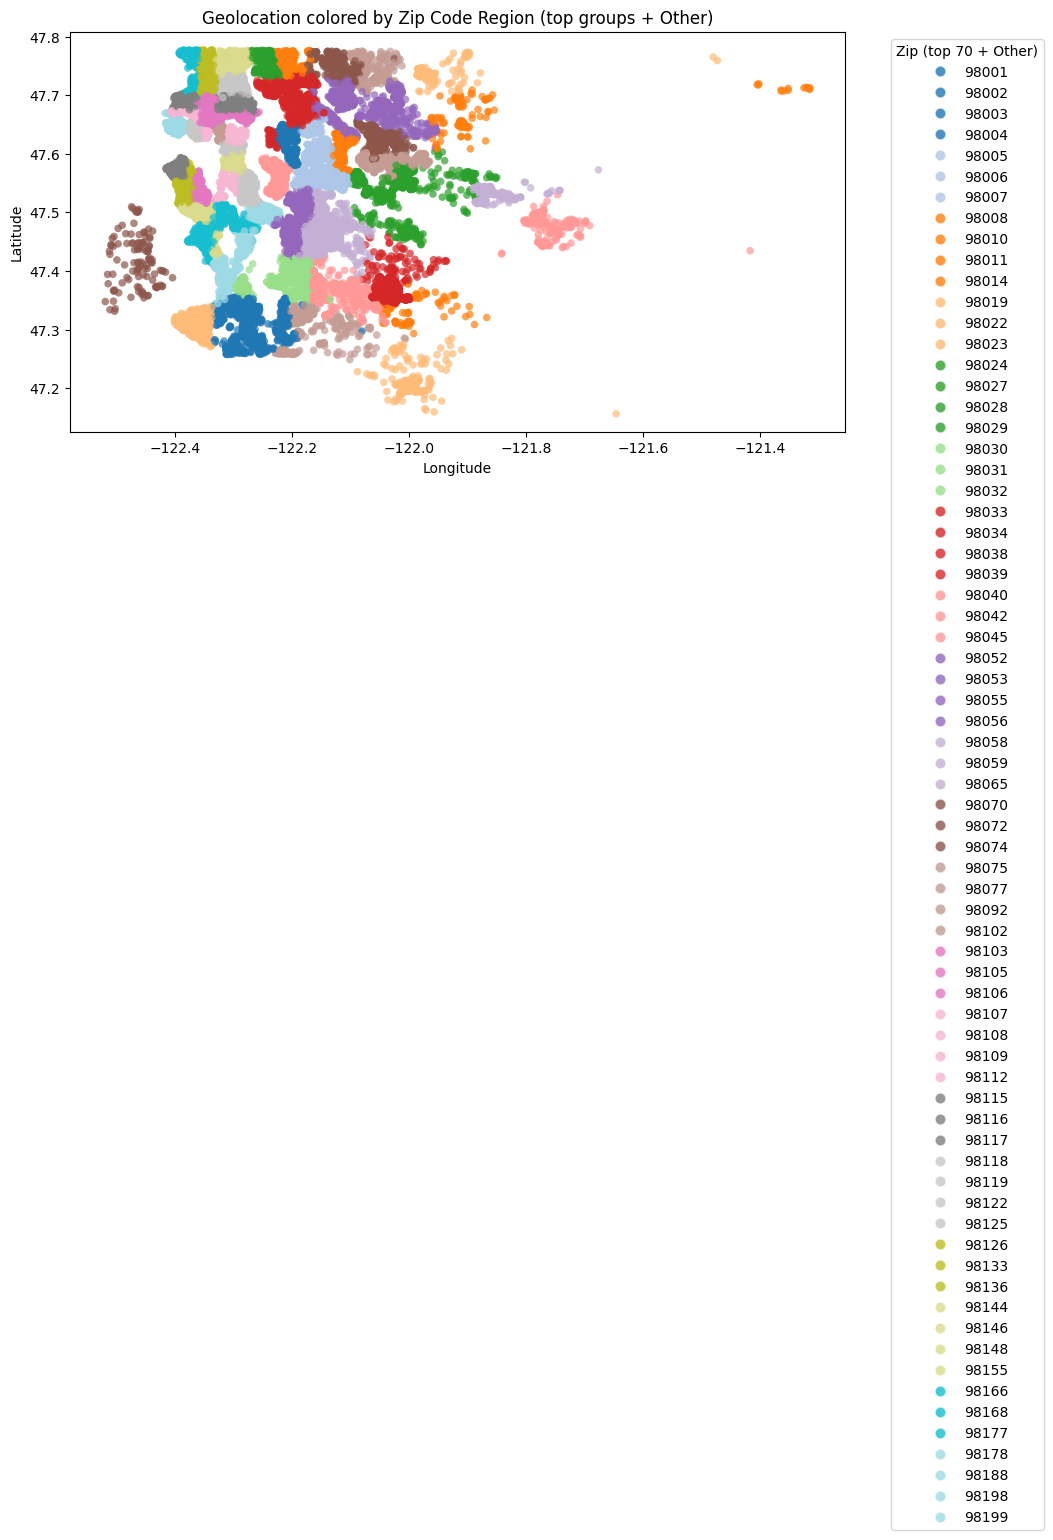

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
%matplotlib inline

# candidates for lat/lon and zip columns
lat_candidates = ['lat', 'latitude', 'Lat', 'Latitude']
lon_candidates = ['long', 'lon', 'longitude', 'Long', 'Longitude']
zip_candidates = ['zip', 'zipcode', 'zip_code', 'postalcode', 'postal_code', 'ZIP', 'Zipcode']

lat_col = next((c for c in lat_candidates if c in df_import.columns), None)
lon_col = next((c for c in lon_candidates if c in df_import.columns), None)
'zipcode' = next((c for c in zip_candidates if c in df_import.columns), None)

if lat_col is None or lon_col is None or 'zipcode' is None:
    print("Required columns missing. Available columns:", list(df_import.columns))
else:
    # prepare data
    df_plot = df_import.copy()
    df_plot[lat_col] = pd.to_numeric(df_plot[lat_col], errors='coerce')
    df_plot[lon_col] = pd.to_numeric(df_plot[lon_col], errors='coerce')
    df_plot['zipcode'] = df_plot['zipcode'].astype(str).str.strip().replace({'nan': None})

    df_plot = df_plot.dropna(subset=[lat_col, lon_col, 'zipcode'])
    if df_plot.empty:
        print("No valid rows with lat/lon/zip to plot.")
    else:
        # keep top N zip codes, group the rest as "Other"
        top_n = 70
        top_zips = df_plot['zipcode'].value_counts().nlargest(top_n).index.tolist()
        df_plot['zip_group'] = df_plot['zipcode'].where(df_plot['zipcode'].isin(top_zips), 'Other')

        cats = pd.Categorical(df_plot['zip_group'])
        codes = cats.codes
        n_colors = len(cats.categories)
        cmap = plt.get_cmap('tab20', max(1, n_colors))

        plt.figure(figsize=(10, 8))
        sc = plt.scatter(
            df_plot[lon_col],
            df_plot[lat_col],
            c=codes,
            cmap=cmap,
            s=30,
            alpha=0.7,
            linewidth=0
        )
        plt.title('Geolocation colored by Zip Code Region (top groups + Other)')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.gca().set_aspect('equal', adjustable='box')

        # legend for categorical zip groups
        handles = []
        labels = []
        for i, cat in enumerate(cats.categories):
            handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                      markerfacecolor=cmap(i), markersize=8, alpha=0.8))
            labels.append(cat)
        plt.legend(handles, labels, title=f'Zip (top {top_n} + Other)', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
# ...existing code...

3d plot

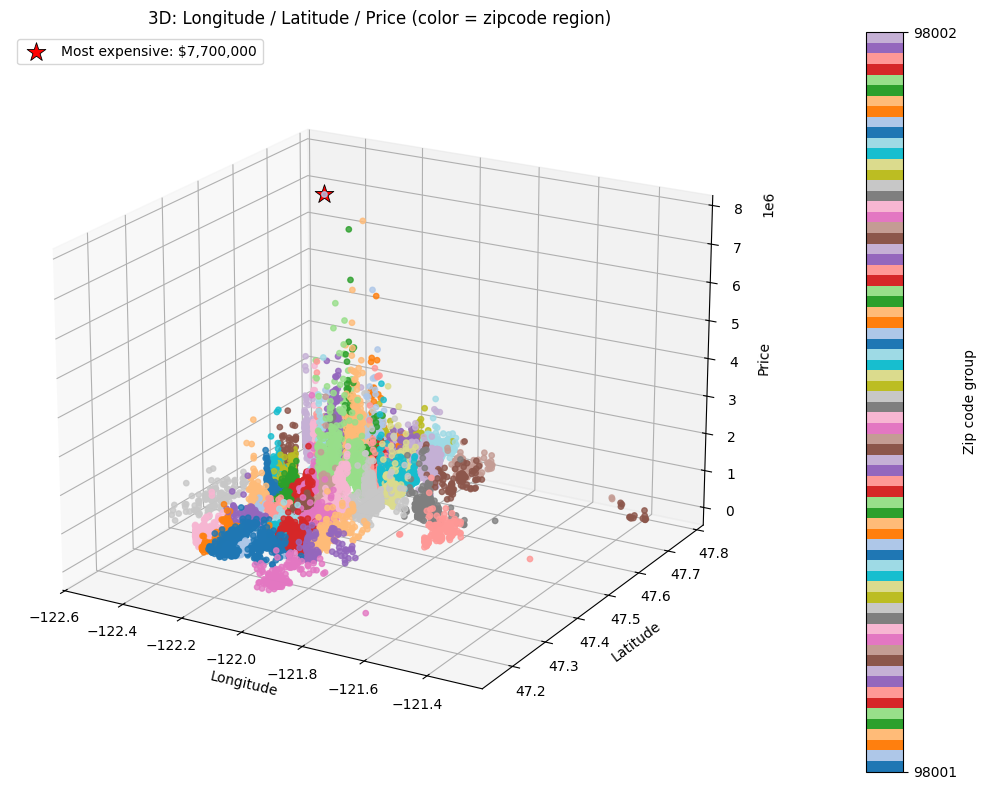

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
%matplotlib inline

# detect lat/lon and zip like before
lat_candidates = ['lat', 'latitude', 'Lat', 'Latitude']
lon_candidates = ['long', 'lon', 'longitude', 'Long', 'Longitude']
zip_candidates = ['zip', 'zipcode', 'zip_code', 'postalcode', 'postal_code', 'ZIP', 'Zipcode']

lat_col = next((c for c in lat_candidates if c in df_import.columns), None)
lon_col = next((c for c in lon_candidates if c in df_import.columns), None)
'zipcode' = next((c for c in zip_candidates if c in df_import.columns), None)

if lat_col is None or lon_col is None or 'zipcode' is None or 'price' not in df_import.columns:
    print("Need latitude, longitude, zipcode and price columns. Available:", list(df_import.columns))
else:
    # prepare and coerce types
    df_import[lat_col] = pd.to_numeric(df_import[lat_col], errors='coerce')
    df_import[lon_col] = pd.to_numeric(df_import[lon_col], errors='coerce')
    df_import['price'] = pd.to_numeric(df_import['price'], errors='coerce')
    df_import['zipcode'] = df_import['zipcode'].astype(str).str.strip().replace({'nan': None})

    # drop invalid rows
    df_3d = df_import.dropna(subset=[lat_col, lon_col, 'price', 'zipcode']).copy()
    if df_3d.empty:
        print("No valid rows to plot.")
    else:
        # limit categories to top N zip codes, group rest as 'Other'
        top_n = 70
        top_zips = df_3d['zipcode'].value_counts().nlargest(top_n).index.tolist()
        df_3d['zip_group'] = df_3d['zipcode'].where(df_3d['zipcode'].isin(top_zips), 'Other')

        cats = pd.Categorical(df_3d['zip_group'])
        codes = cats.codes  # numeric codes for coloring
        n_colors = len(cats.categories)

        # create a qualitative colormap with enough colors
        base_cmap = plt.get_cmap('tab20')
        # if more colors needed, tile the base map
        colors = [base_cmap(i % base_cmap.N) for i in range(n_colors)]
        cmap = ListedColormap(colors)

        # optionally downsample for performance
        # if len(df_3d) > 30000:
        #     df_3d = df_3d.sample(30000, random_state=0)
        #     codes = pd.Categorical(df_3d['zip_group']).codes

        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')

        # z axis = price, color = zipcode group codes
        sc = ax.scatter(
            df_3d[lon_col],
            df_3d[lat_col],
            df_3d['price'],
            c=codes,
            cmap=cmap,
            s=15,
            alpha=0.8,
            depthshade=True
        )

        # create colorbar with categorical labels
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array([])
        cbar = fig.colorbar(mappable, ax=ax, pad=0.1, ticks=range(n_colors))
        cbar.ax.set_yticklabels(cats.categories)
        cbar.set_label('Zip code group')

        # highlight the most expensive point
        idx_max = df_3d['price'].idxmax()
        most_exp = df_3d.loc[idx_max]
        ax.scatter(
            most_exp[lon_col],
            most_exp[lat_col],
            most_exp['price'],
            color='red',
            s=200,
            marker='*',
            edgecolor='k',
            linewidth=0.6,
            label=f"Most expensive: ${int(most_exp['price']):,}"
        )

        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_zlabel('Price')
        ax.set_title('3D: Longitude / Latitude / Price (color = zipcode region)')
        ax.view_init(elev=20, azim=-60)
        ax.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
# ...existing code...

price vs zipcode

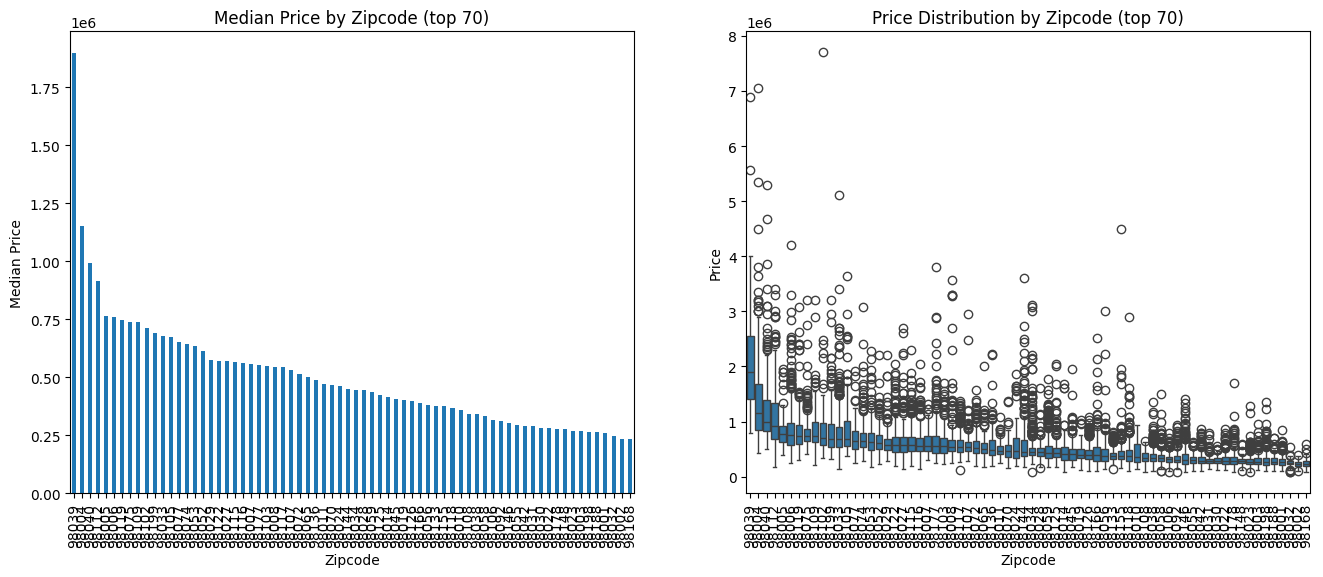

In [66]:
# ...existing code...
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = df_import.copy()
df['zipcode'] = df['zipcode'].astype(str).str.strip().replace({'nan': None})
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['zipcode', 'price']).copy()

if df.empty:
    print("No valid rows with zipcode and price.")
else:
    top_n = 70
    top_zips = df['zipcode'].value_counts().nlargest(top_n).index.tolist()
    df_top = df[df['zipcode'].isin(top_zips)].copy()
    # order by median price for nicer plots
    order = df_top.groupby('zipcode')['price'].median().sort_values(ascending=False).index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios':[1,1]})

    # median price bar chart
    medians = df_top.groupby('zipcode')['price'].median().reindex(order)
    medians.plot.bar(ax=axes[0], color='C0')
    axes[0].set_title('Median Price by Zipcode (top {})'.format(top_n))
    axes[0].set_xlabel('Zipcode')
    axes[0].set_ylabel('Median Price')
    axes[0].tick_params(axis='x', rotation=90)

    # price distribution boxplot
    sns.boxplot(x='zipcode', y='price', data=df_top, order=order, ax=axes[1])
    axes[1].set_title('Price Distribution by Zipcode (top {})'.format(top_n))
    axes[1].set_xlabel('Zipcode')
    axes[1].set_ylabel('Price')
    axes[1].tick_params(axis='x', rotation=90)

    plt.show()
# ...existing code...

central zipcodes

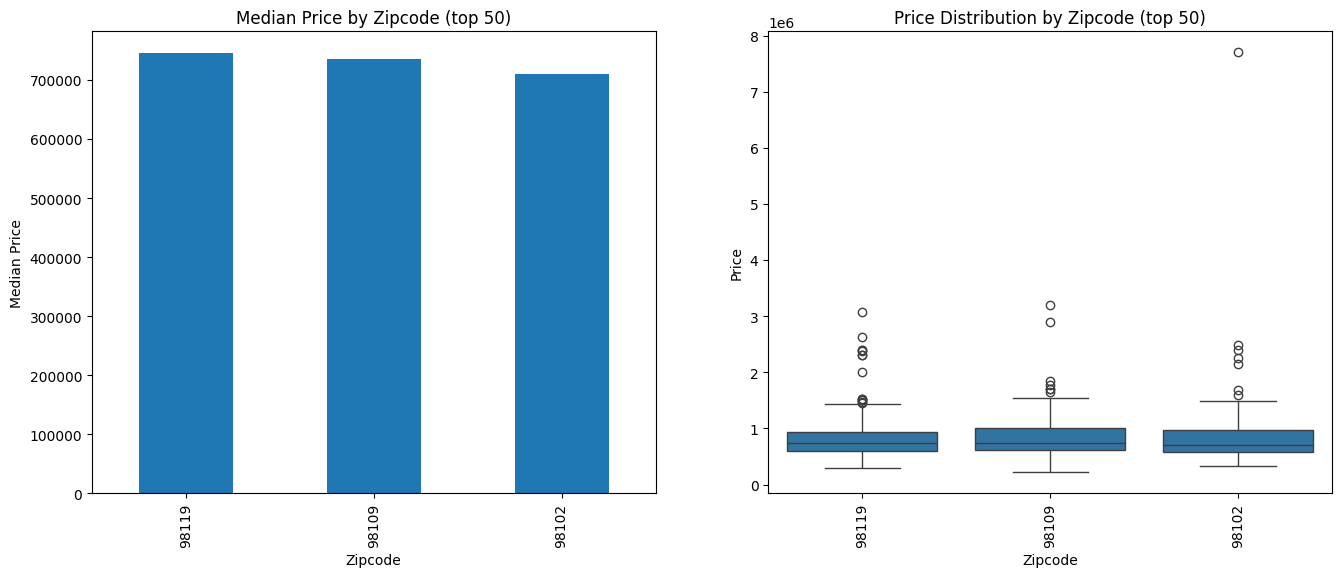

In [72]:
# ...existing code...
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = df_import.copy()
df['zipcode'] = df['zipcode'].astype(str).str.strip().replace({'nan': None})
central_zips = ['98101', '98102', '98109', '98119']
df = df[df['zipcode'].isin(central_zips)].copy()
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['zipcode', 'price']).copy()

if df.empty:
    print("No valid rows with zipcode and price.")
else:
    top_n = 50
    top_zips = df['zipcode'].value_counts().nlargest(top_n).index.tolist()
    df_top = df[df['zipcode'].isin(top_zips)].copy()
    # order by median price for nicer plots
    order = df_top.groupby('zipcode')['price'].median().sort_values(ascending=False).index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios':[1,1]})

    # median price bar chart
    medians = df_top.groupby('zipcode')['price'].median().reindex(order)
    medians.plot.bar(ax=axes[0], color='C0')
    axes[0].set_title('Median Price by Zipcode (top {})'.format(top_n))
    axes[0].set_xlabel('Zipcode')
    axes[0].set_ylabel('Median Price')
    axes[0].tick_params(axis='x', rotation=90)

    # price distribution boxplot
    sns.boxplot(x='zipcode', y='price', data=df_top, order=order, ax=axes[1])
    axes[1].set_title('Price Distribution by Zipcode (top {})'.format(top_n))
    axes[1].set_xlabel('Zipcode')
    axes[1].set_ylabel('Price')
    axes[1].tick_params(axis='x', rotation=90)

    plt.show()
# ...existing code...